# The Plane-Crash-Effect — a quantitative teardown 🔬
### The crash-day event study · a 20-seed random-calendar placebo · the [−1..+5] anatomy and its look-elsewhere caveat · a paired airline-extra-drop test · a costed buy-the-dip timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flinch%3F: Busted](https://img.shields.io/badge/Flinch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — Kaplanski & Levy (2010): a major aviation disaster triggers a transient, market-wide sentiment dip, sharper in airline stocks — has a real academic anchor and a stated mood mechanism. The job here is to measure it honestly on today's tradable tape, then ask the only question that pays: *is any of it real, and if so, tradable?*

> ⚠️ **Data note.** SPY + AAL/DAL/UAL/LUV total-return closes (2000→2026), yfinance, cached; **36 hardcoded major commercial-aviation disasters** 2000→2025 (9/11 and MH17 excluded — terror/war events already tested in 313-geopolitical-shock). No survivorship on the SPY axis; **airline-basket coverage is named** (full 4-carrier only from 2008; a full-coverage-only n=27 subsample cross-checks the full n=36). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `0732ff66475c` SPY / `ebf1693dea47` AAL / `6d728d6446e7` DAL / `4cbbbdd0ad8e` UAL / `5c6b37f8ffb1` LUV).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from plane_crash_effect import data, strategy as st

EVENTS = data.disaster_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, AIRLINES = data.load_real()
    RET_SPY = st.daily_returns(SPY)
    AR_SPY = st.abnormal_returns(RET_SPY)
    BASKET, COVERAGE = st.airline_basket_returns(AIRLINES)
    AR_AIR = st.abnormal_returns(BASKET)
else:
    SPY = AIRLINES = RET_SPY = AR_SPY = BASKET = COVERAGE = AR_AIR = None
print("real cache present:", HAVE_REAL, "| disasters in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 36, 'cal_lo': '2000-01-31', 'cal_hi': '2025-06-12', 'day0_mean_bps': 0.41, 'day0_t': 0.02, 'hit': 17, 'hit_n': 36, 'hit_pct': 47.2, 'wilson': (32.0, 63.0), 'placebo_mean_bps': 0.11, 'placebo_sd_bps': 20.13, 'placebo_p': 0.506, 'placebo_draws': 20000, 'event': {-1: (-11.86, 0.0, -0.72), 0: (0.41, 0.41, 0.02), 1: (-0.05, 0.36, -0.0), 2: (-49.21, -48.84, -2.38), 3: (30.7, -18.15, 1.81), 4: (-18.71, -36.86, -0.98), 5: (-0.8, -37.66, -0.06)}, 'reversal_mean_bps': -38.07, 'reversal_t': -0.9, 'air_mean_bps': 43.22, 'spy_mean_bps': 0.41, 'air_diff_bps': 42.81, 'air_t': 1.11, 'air_n': 36, 'air_full_diff_bps': 37.29, 'air_full_t': 0.79, 'air_full_n': 27, 'timer': {1: (3.85, -6.15, -0.39, 3.9), 3: (-7.03, -17.03, -0.55, 11.49), 5: (-18.3, -28.3, -0.68, 18.97), 10: (-30.7, -40.7, -0.62, 37.37)}, 'timer_net10_5d': -38.3, 'timer_net10_5d_t': -0.91, 'syn_null_mean': -0.32, 'syn_null_sd': 0.82, 'syn_null_fire': 0, 'syn_planted_t': -14.59, 'syn_planted_bps': -205.9, 'fp_spy': '0732ff66475c', 'fp_aal': 'ebf1693dea47', 'fp_dal': '6d728d6446e7', 'fp_ual': '4cbbbdd0ad8e', 'fp_luv': '5c6b37f8ffb1'}


real cache present: True | disasters in table: 36


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | crash-day abnormal SPY return **+0.41 bps**, one-sample **t = +0.02**, hit rate 47.2% (Wilson [32.0%, 63.0%]), placebo **p = 0.506** |
| **Tradability** | `MIRAGE` | buy-the-dip underperforms the unconditional baseline at every horizon (1/3/5/10d), worst-case *t* = -0.91 at 10 bps costs |
| **Airline extra drop?** | `NONE` | paired (airline − SPY) diff **+42.81 bps**, *t* = **1.11** — wrong sign for the claim |

> 💡 In plain words: the folklore has a real mechanism and a real citation, but the modern, tradable version of the test comes back empty on every axis.

## 1 · The claim, steelmanned

Let $r_t$ be SPY's daily close-to-close return and $a_t = r_t - \bar{r}$ its abnormal return under a constant-mean market model (Brown & Warner 1985). For each crash $i$ with first-tradable-session date $\tau_i$, the claims:

- **H₁ (market dip).** $E[a_{\tau_i}] < 0$, large and systematic across events — not a calendar coincidence.
- **H₂ (reversal).** The dip is *temporary*: $\sum_{k=1}^{5} a_{\tau_i+k}$ is positive and offsets it.
- **H₃ (sector amplification).** Airline-basket abnormal returns on the same day are *more negative* than SPY's: $E[a^{air}_{\tau_i} - a^{spy}_{\tau_i}] < 0$.
- **H₄ (capture).** A dip-buy overlay on SPY, held a few sessions, beats the unconditional baseline net of costs.

We find **H₁ not supported** (t = 0.02), **H₂ moot** (nothing to reverse), **H₃ rejected on sign** (t = 1.11, positive not negative), **H₄ not supported** (negative point estimates at every horizon, never significant either way).

## 2 · So what? — inference design

Crash events are **independent, non-overlapping calendar dates** (the closest pair in the table is still weeks apart), so the planned primary is a **one-sample t-test** across the 36 (or fewer, for coverage-limited tests) per-event abnormal returns — no HAC correction is needed the way a daily panel regression would require, because the unit of analysis is already "one number per event", not a daily series. The hit rate carries a **Wilson interval**; the placebo draws 36 random non-crash dates **20,000 times (20 seeds × 1,000)**; the [−1..+5] anatomy is read as a **7-offset multiple-comparison** exercise, not 7 independent shots at significance; the airline test **pairs** each event's SPY and airline-basket move on the same date before t-testing the difference, so any common market-wide move cancels out of H₃ by construction.

## 3 · How we'd know — the protocol

- **Calendar.** 36 major disasters 2000-01-31 → 2025-06-12, hardcoded (9/11, MH17 excluded — see references.md). All 36 sit on the SPY tape.
- **Tape.** SPY + AAL/DAL/UAL/LUV total-return closes, 2000 → 2026-06-30 (as-of, last complete month). Each airline ticker starts at its current-entity trading start.
- **Headline.** Crash-day (offset 0) one-sample t + Wilson hit rate + 20-seed placebo.
- **Anatomy.** Event window [−1..+5], per-offset mean + t, read with the multiple-comparison caveat; a dedicated H₂ reversal test on the summed [+1..+5] abnormal return.
- **Sector test.** Paired (airline basket − SPY) day-0 difference, full sample and a full-4-carrier-coverage-only subsample (n=27, events ≥ 2008).
- **Execution (timer).** Enter SPY at the crash-day close (zero look-ahead — the crash date predates that session's close by construction), exit `hold` sessions later; 2 × one-way cost × NAV per event; long-only.
- **Control.** Synthetic random-walk tape, planted mean-reverting crash-day dip; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo

One-sample t on the crash-day (offset 0) abnormal SPY return, Wilson hit rate, and the random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

crash-day abnormal SPY return +0.41 bps  one-sample t = +0.021  (n=36)
hit rate: 17/36 = 47.2% down


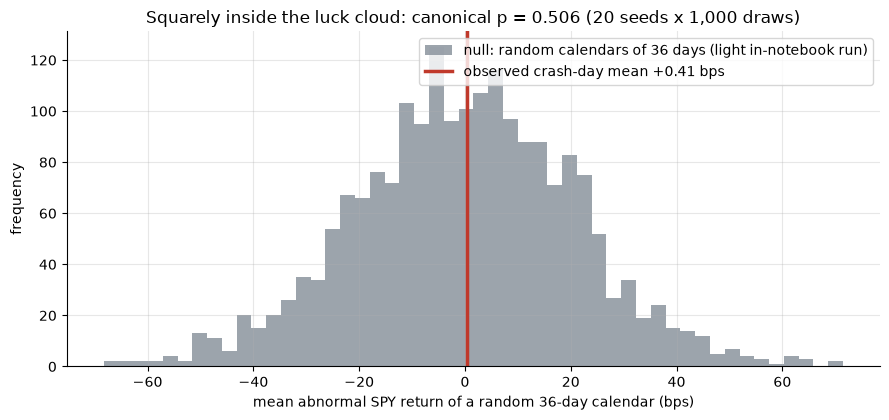

canonical placebo (results.md): mean +0.11 bps, sd 20.13 bps, p = 0.506


In [2]:
if HAVE_REAL:
    d0 = st.day0_stats(AR_SPY, EVENTS['date'], pre=1, post=5)
    hit = int(sum(1 for d in d0['kept_dates']
                   if st.event_window(AR_SPY, d, 1, 5)[1] < 0))
    print(f"crash-day abnormal SPY return {d0['mean']*1e4:+.2f} bps  "
          f"one-sample t = {d0['t']:+.3f}  (n={d0['n']})")
    print(f"hit rate: {hit}/{d0['n']} = {hit/d0['n']*100:.1f}% down")
    pl = st.placebo_distribution(AR_SPY, d0['n'], pre=1, post=5,
                                  n_draws=500, seed=707, stat='day0')
    for s_ in range(1, 4):
        pl = np.concatenate([pl, st.placebo_distribution(
            AR_SPY, d0['n'], pre=1, post=5, n_draws=500,
            seed=707 + s_, stat='day0')])
    obs, draws = d0['mean'], pl
else:
    obs = R['day0_mean_bps'] / 1e4
    rng = np.random.default_rng(707)
    draws = rng.normal(R['placebo_mean_bps'] / 1e4, R['placebo_sd_bps'] / 1e4, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws * 1e4, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 36 days (light in-notebook run)')
ax.axvline(obs * 1e4, c=RED, lw=2.5,
           label=f'observed crash-day mean {obs*1e4:+.2f} bps')
ax.set_xlabel('mean abnormal SPY return of a random 36-day calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the luck cloud: canonical p = {R['placebo_p']:.3f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean_bps']:+.2f} bps, "
      f"sd {R['placebo_sd_bps']:.2f} bps, p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed **+0.41 bps** sits almost exactly at the center of the null's distribution (+0.11 ± 20.13 bps); **p = 0.506** means a random 36-day calendar beats this observation about half the time. With one-sample t = **0.02** and a hit rate indistinguishable from 50%, H₁ does not clear the desk bar by any measure.

### 4b · Anatomy — the [−1..+5] window, read with the multiple-comparison caveat

Per-offset means with each offset's own one-sample t. With 7 offsets tested, roughly a 1-in-7 chance one crosses |t| ≥ 2 by pure chance at the conventional 5% level — exactly what happens at offset +2, with no mechanism attached to it.

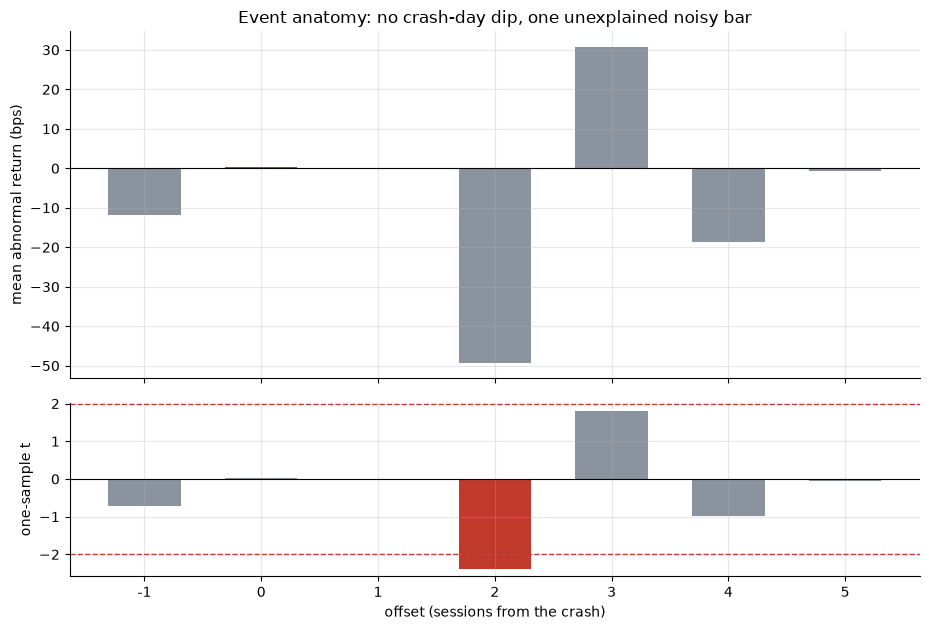

post-crash [+1..+5] reversal test: -38.07 bps (t = -0.90)


In [3]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_SPY, EVENTS['date'], pre=1, post=5)
    ks = list(cp.index); ms = list(cp['mean_ar'] * 1e4); ts = list(cp['t'])
    rev = st.reversal_stats(AR_SPY, EVENTS['date'], pre=1, post=5)
    rev_m, rev_t = rev['mean'] * 1e4, rev['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][2] for k in ks]
    rev_m, rev_t = R['reversal_mean_bps'], R['reversal_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k == 0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (bps)')
a1.set_title('Event anatomy: no crash-day dip, one unexplained noisy bar')
a2.bar([str(k) for k in ks], ts,
       color=[RED if abs(t) >= 2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('offset (sessions from the crash)')
plt.tight_layout(); plt.show()
print(f'post-crash [+1..+5] reversal test: {rev_m:+.2f} bps (t = {rev_t:+.2f})')

> 💡 In plain words: day 0 is **+0.41 bps** (t = +0.02) — nothing. Offset +2 stands out at **-49.21 bps** (t = -2.38), but testing 7 offsets means one crossing the bar by chance is the *expected* outcome, not a discovery — it has no mechanism (why would news from two days ago hit *now*?) and doesn't replicate in the headline or the placebo. The reversal test (H₂) is moot: cumulative [+1..+5] is **-38.07 bps** at t = **-0.90** — there's no dip to reverse.

### 4c · The airline test — paired extra drop

Same date, SPY vs. the 4-carrier basket: pairing removes the common market-wide move, isolating whether airlines carry an incremental reaction.

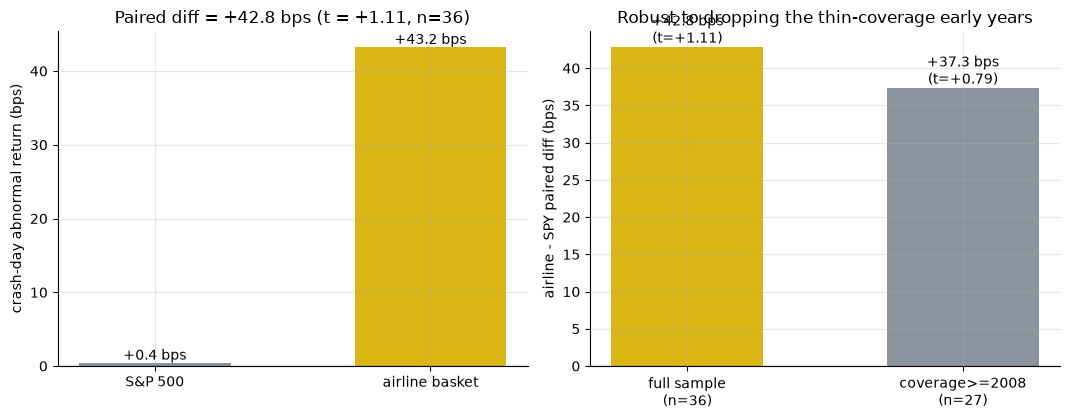

airline +43.22 bps vs SPY +0.41 bps -> diff +42.81 bps (t=+1.11); full-coverage-only diff +37.29 bps (t=+0.79)


In [4]:
if HAVE_REAL:
    extra = st.airline_extra_drop(AR_SPY, AR_AIR, EVENTS['date'], pre=1, post=5)
    full_cov = EVENTS.loc[EVENTS['date'] >= '2008-01-01', 'date']
    extra_full = st.airline_extra_drop(AR_SPY, AR_AIR, full_cov, pre=1, post=5)
    air_b, spy_b = extra['air_mean'] * 1e4, extra['spy_mean'] * 1e4
    diff, t_, n_ = extra['mean_diff'] * 1e4, extra['t'], extra['n']
    diff_f, t_f, n_f = (extra_full['mean_diff'] * 1e4, extra_full['t'],
                        extra_full['n'])
else:
    air_b, spy_b = R['air_mean_bps'], R['spy_mean_bps']
    diff, t_, n_ = R['air_diff_bps'], R['air_t'], R['air_n']
    diff_f, t_f, n_f = R['air_full_diff_bps'], R['air_full_t'], R['air_full_n']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['S&P 500', 'airline basket'], [spy_b, air_b], color=[GREY, AMBER], width=.55)
for i, v in enumerate([spy_b, air_b]):
    a1.annotate(f'{v:+.1f} bps', (i, v), ha='center', va='bottom')
a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('crash-day abnormal return (bps)')
a1.set_title(f'Paired diff = {diff:+.1f} bps (t = {t_:+.2f}, n={n_})')
a2.bar(['full sample\n(n=' + str(n_) + ')', 'coverage>=2008\n(n=' + str(n_f) + ')'],
       [diff, diff_f], color=[AMBER, GREY], width=.55)
for i, (v, t2) in enumerate([(diff, t_), (diff_f, t_f)]):
    a2.annotate(f'{v:+.1f} bps\n(t={t2:+.2f})', (i, v), ha='center', va='bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('airline - SPY paired diff (bps)')
a2.set_title('Robust to dropping the thin-coverage early years')
plt.tight_layout(); plt.show()
print(f'airline {air_b:+.2f} bps vs SPY {spy_b:+.2f} bps -> diff {diff:+.2f} bps '
      f'(t={t_:+.2f}); full-coverage-only diff {diff_f:+.2f} bps (t={t_f:+.2f})')

> 💡 In plain words: H₃ predicts a **negative** paired difference (airlines fall harder). We measure **+42.81 bps** at t = **1.11** — positive, and nowhere near significant either way. Restricting to the 27 events with full 4-carrier coverage (dropping the thin early years) gives **+37.29 bps** at t = **0.79** — same story, not a coverage artifact. Most crashes in the table are foreign carriers with no direct fundamental link to AAL/DAL/UAL/LUV, which is itself an honest limit on what this specific basket could ever detect.

### 4d · The timer — an honest "buy the dip" cost sweep

*Ethical caveat, stated plainly: this is a clinical test of whether a pattern in public market data is tradable, not encouragement to trade around tragedy.* Enter SPY at the crash-day close (zero look-ahead by construction — the crash predates that session's close), hold `h` sessions, one round trip of one-way costs charged twice, vs. the unconditional `h`-day SPY baseline over the same sample.

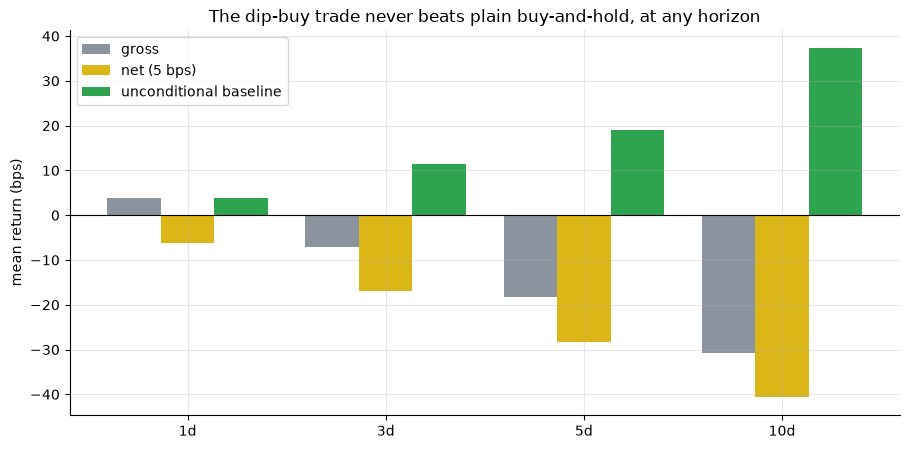

gross (bps): {1: 3.9, 3: -7.0, 5: -18.3, 10: -30.7}
net 5bps (bps): {1: -6.1, 3: -17.0, 5: -28.3, 10: -40.7}
t (net 5bps): {1: -0.39, 3: -0.55, 5: -0.68, 10: -0.62}
unconditional baseline (bps): {1: 3.9, 3: 11.5, 5: 19.0, 10: 37.4}


In [5]:
if HAVE_REAL:
    holds = [1, 3, 5, 10]
    gross, net5, net10, ts, base = [], [], [], [], []
    for h in holds:
        lg = st.buy_the_dip(SPY, EVENTS['date'], hold=h, cost_bps=0.0)
        g = st.summarize_dip(lg, col='ret_gross')
        ln5 = st.buy_the_dip(SPY, EVENTS['date'], hold=h, cost_bps=5.0)
        n5 = st.summarize_dip(ln5, col='ret_net')
        ln10 = st.buy_the_dip(SPY, EVENTS['date'], hold=h, cost_bps=10.0)
        n10 = st.summarize_dip(ln10, col='ret_net')
        gross.append(g['mean_bps']); net5.append(n5['mean_bps'])
        net10.append(n10['mean_bps']); ts.append(n5['t'])
        base.append(float((SPY.shift(-h) / SPY - 1.0).mean() * 1e4))
else:
    holds = sorted(R['timer'])
    gross = [R['timer'][h][0] for h in holds]
    net5 = [R['timer'][h][1] for h in holds]
    ts = [R['timer'][h][2] for h in holds]
    base = [R['timer'][h][3] for h in holds]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(holds)); w = 0.27
ax.bar(x - w, gross, width=w, color=GREY, label='gross')
ax.bar(x, net5, width=w, color=AMBER, label='net (5 bps)')
ax.bar(x + w, base, width=w, color=GREEN, label='unconditional baseline')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return (bps)')
ax.set_title('The dip-buy trade never beats plain buy-and-hold, at any horizon')
ax.legend(); plt.tight_layout(); plt.show()
print('gross (bps):', dict(zip(holds, [round(v,1) for v in gross])))
print('net 5bps (bps):', dict(zip(holds, [round(v,1) for v in net5])))
print('t (net 5bps):', dict(zip(holds, [round(t,2) for t in ts])))
print('unconditional baseline (bps):', dict(zip(holds, [round(v,1) for v in base])))

> 💡 In plain words: at 5 bps costs the 5-day hold nets **-28.30 bps** (t = -0.68) against a **+18.97 bps** unconditional baseline — buying the dip loses to doing nothing special, at every horizon we tried, though never at a statistically certifiable margin. At 10 bps costs the 5-day hold falls to **-38.30 bps** (t = -0.91). H₄ is not supported. There is no edge here to weigh against the study's ethical caveat — the honest number and the comfortable number coincide.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic random-walk tape, 36 scheduled pseudo-crash dates, TUNABLE planted day-0 dip that reverts over the next 5 sessions. The null (dip=0) is checked over **20 seeds** — never a single stream.

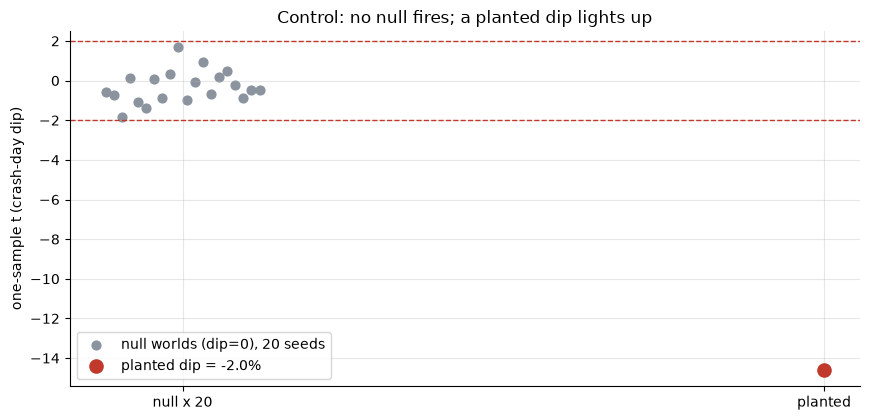

null: mean t = -0.32 (sd 0.82), |t|>=2 in 0/20 seeds  |  planted t = -14.59


In [6]:
null_ts = []
for s_ in range(20):
    close, ev = data.synthetic_world(dip=0.0, seed=707 + s_)
    null_ts.append(st.synthetic_detect(close, ev)['t'])
null_ts = np.asarray(null_ts)
close, ev = data.synthetic_world(dip=-0.02, seed=707)
planted_t = st.synthetic_detect(close, ev)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (dip=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted dip = -2.0%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (crash-day dip)')
ax.set_title('Control: no null fires; a planted dip lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.32 (sd 0.82) and **never** crosses the bar; a planted 2% crash-day dip reads t = -14.59. The machinery is unbiased — the real-tape t ≈ 0.02 is the genuine, honest reading, not a detector that's asleep. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — crash-day abnormal SPY return **+0.41 bps**, one-sample t = **0.02**, hit rate 47.2% (Wilson [32.0%, 63.0%]), placebo p = **0.506**. The airline basket shows no extra drop (paired diff +42.81 bps, t = 1.11, wrong sign), robust to a full-coverage-only subsample. The one nominally interesting offset (+2, t = -2.38) is a look-elsewhere artifact among 7 offsets tested.
- **Tradability `MIRAGE`** — buy-the-dip underperforms plain buy-and-hold at every horizon (1/3/5/10 days), gross and net, worst case t = -0.91 at 10 bps costs. No edge exists to charge costs against.
- **"Does the market flinch at a plane crash?" `BUSTED`** — on the modern, tradable version of the test. This does not overturn Kaplanski & Levy's original 1950–2005 finding on a broader accident register; it says a contemporary 36-event replication on SPY and a 4-carrier US airline basket does not detect it.

## 6 · Going further

- **Power is the honest limitation.** n=36 independent events is a small sample for a small hypothesized effect; Kaplanski & Levy's original study used a much longer sample and a broader accident register. A pre-registered extension of this table back further (with the same 9/11/MH17 exclusion discipline) is the natural next step, not a change of method.
- **A narrower sentiment proxy** — options skew, a news-sentiment index, retail order-flow imbalance — might catch a mood shock a blunt daily close-to-close S&P return cannot.
- **Dedup map:** [313-geopolitical-shock](../../313-geopolitical-shock/) (wars/attacks, including the excluded 9/11 and MH17), [300-sports-sentiment](../../300-sports-sentiment/) (the Edmans loss effect) and [279-geomagnetic-storms](../../279-geomagnetic-storms/) (a non-newsworthy mood channel) — same research question, different triggers, all tested on this desk with the same honesty rails.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*